In [137]:
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt

In [138]:
dataset = load_dataset("lukebarousse/data_jobs")
df = dataset["train"].to_pandas()

In [139]:
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])

In [140]:
df_us = df[df['job_country'] == 'United States'].copy()

In [141]:
#df['job_posted_month'] = df.job_posted_date.dt.month
df_us['job_posted_month'] = df_us.job_posted_date.dt.strftime('%B')

In [142]:
df_us_month = df_us.pivot_table(
    index= 'job_posted_month',
    columns= 'job_title_short',
    aggfunc='size'
)

In [143]:
df_us_month.reset_index(inplace=True)

In [144]:
df_us_month['month_num'] = pd.to_datetime(df_us_month['job_posted_month'] , format='%B').dt.month 

In [145]:
df_us_month.sort_values(by='month_num' , inplace=True)

In [146]:
df_us_month.set_index('job_posted_month', inplace=True)

In [147]:
df_us_month.drop(columns='month_num', inplace=True )

In [163]:
top3 = df_us.value_counts('job_title_short').head(3)

df_us_month = df_us_month[top3.index.tolist()]

In [164]:
df_us_month

job_title_short,Data Analyst,Data Scientist,Data Engineer
job_posted_month,,,
January,8494,6915,2655
February,6124,4956,3060
March,6218,4779,3183
April,6049,4867,2801
May,4993,4377,2976
June,5683,4645,2893
July,5201,4876,2570
August,6634,6318,3269
September,4639,4568,3224


<Axes: xlabel='job_posted_month'>

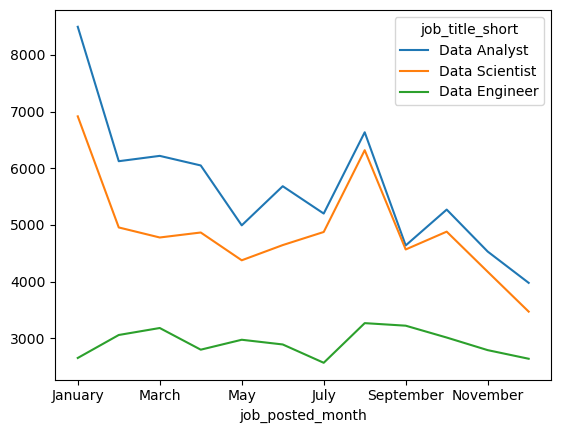

In [165]:
df_us_month.plot(kind='line')